In [8]:
import numpy as np
import torch
import pandas as pd
import h5py
from src.interpolate import shift_spectra_linear
from src.ccf import compute_CCFs, get_full_ccf_analysis
from astropy.timeseries import LombScargle
from torch.utils.data import DataLoader

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import pathlib

# 1) D'abord fixer le style de base
plt.style.use("default")  # ou un autre style si tu veux

# 2) Ensuite seulement surcharger avec tes rcParams
mpl.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.framealpha": 0.9,
        "legend.fancybox": False,
        "figure.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.dpi": 300,
        "savefig.format": "pdf",
        "axes.grid": False,
        "grid.alpha": 0.8,
        "grid.linestyle": ":",
    }
)

In [9]:
colab_periodogram_files = []
for path in pathlib.Path("../experiments").rglob("*colab/postprocessing/data/periodograms.npz"):
    colab_periodogram_files.append(path)

print(f"Trouvé {len(colab_periodogram_files)} fichiers periodograms.npz :")
for f in colab_periodogram_files:
    data = np.load(f, allow_pickle=True)
    print(f" - {f}: {data.files}")


Trouvé 4 fichiers periodograms.npz :
 - ../experiments/aestra_baseline_1000_spectra_activity_proxies_colab/postprocessing/data/periodograms.npz: ['v_apparent_periods', 'v_apparent_power', 'v_encode_periods', 'v_encode_power', 'v_correct_periods', 'v_correct_power', 'v_traditionnal_periods', 'v_traditionnal_power', 'v_ref_periods', 'v_ref_power', 's_1_periods', 's_1_power', 's_2_periods', 's_2_power', 's_3_periods', 's_3_power']
 - ../experiments/aestra_baseline_1000_spectra_brest_true_loss_smooth_colab/postprocessing/data/periodograms.npz: ['v_apparent_periods', 'v_apparent_power', 'v_encode_periods', 'v_encode_power', 'v_correct_periods', 'v_correct_power', 'v_traditionnal_periods', 'v_traditionnal_power', 'v_ref_periods', 'v_ref_power', 's_1_periods', 's_1_power', 's_2_periods', 's_2_power', 's_3_periods', 's_3_power']
 - ../experiments/aestra_baseline_1000_spectra_colab/postprocessing/data/periodograms.npz: ['v_apparent_periods', 'v_apparent_power', 'v_encode_periods', 'v_encode_pow

In [ ]:
# # ============================================
# # Periodograms (Lomb–Scargle) + viewer interactif
# # ============================================
# import numpy as np
# import torch
# from torch.utils.data import DataLoader
# import matplotlib.pyplot as plt
# from src.dataset import generate_collate_fn
# from scipy.signal import lombscargle
# from src.modeling.train import load_experiment_checkpoint
# from src.modeling.predict import (
#     detrend_vencode_with_latent
# )
# ckpt = load_experiment_checkpoint(
#     "../experiments/fine_tuned/models/aestra_final.pth",
#     dataset_filepath="../data/npz_datasets/soapgpu_ns1275_5000-5010_snr2000_p100_k0p5_phi0.npz",
#     device="cpu",
# )

# ckpt_dset = ckpt["dataset"]
# ckpt_model = ckpt["model"]

# # 1) Recréer un DataLoader SANS mélange (ordre temporel)
# collate_fn = generate_collate_fn(ckpt_dset)
# dataloader_ts = DataLoader(
#     ckpt_dset, batch_size=64, shuffle=False, collate_fn=collate_fn
# )

# ckpt_model.eval()
# ckpt_model.to("cpu")

# S_list, vencode_list, yact_norm_list = [], [], []

# with torch.no_grad():
#     for batch in dataloader_ts:
#         yobs = batch[0].to("cpu")  # [B, P]
#         # même prétraitement que chez toi :
#         y_centered = yobs - ckpt_model.b_rest

#         vencode = ckpt_model.rvestimator(y_centered).detach().cpu().numpy().reshape(-1)
#         yact, S = ckpt_model.spender(y_centered)
#         S = S.detach().cpu().numpy()  # [B, 3]
#         yact_norm = np.linalg.norm(yact.detach().cpu().numpy(), axis=1)  # [B]

#         S_list.append(S)
#         vencode_list.append(vencode)
#         yact_norm_list.append(yact_norm)

# S = np.concatenate(S_list, axis=0)  # [N, 3]
# vencode = np.concatenate(vencode_list, axis=0)  # [N]
# yact_norm = np.concatenate(yact_norm_list, axis=0)  # [N]

# # 2) Récupérer les temps (on suppose alignés sur l'ordre du dataset)
# t = np.asarray(ckpt_dset.time_values, dtype=float)  # ex: BJD
# assert t.shape[0] == S.shape[0] == vencode.shape[0] == yact_norm.shape[0], (
#     f"Longueurs incompatibles: t={t.shape}, S={S.shape}, v={vencode.shape}, ||y||={yact_norm.shape}"
# )

/home/tliopis/Codes/exoplanets_llopis_mary_2025/venv/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


[04:59:01] 📂 Loading experiment checkpoint: ../experiments/fine_tuned/models/aestra_final.pth         ]8;id=729649;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=238585;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#193\193]8;;\

In [ ]:
# %matplotlib inline
# import numpy as np
# import matplotlib.pyplot as plt
# from ipywidgets import interact
# from astropy.timeseries import LombScargle

# # detrending (si pas déjà fait)
# v_correct, v0_avg, sigma_R = detrend_vencode_with_latent(vencode, S, knn=10)


# def compute_ls_periodogram(t_days, y, min_period=2.0, max_period=None, oversample=5):
#     """Retourne (periods, power) avec Astropy Lomb–Scargle."""
#     t = np.asarray(t_days, float)
#     y = np.asarray(y, float) - np.mean(y)

#     Tspan = t.max() - t.min()
#     if max_period is None:
#         max_period = 0.9 * Tspan
#     if t.size > 2:
#         dt_med = np.median(np.diff(np.unique(t)))
#         min_period = max(min_period, 2.0 * dt_med)

#     # Grille de fréquences
#     fmin = 1.0 / max_period
#     fmax = 1.0 / min_period
#     N = max(5000, int(oversample * max(1000, t.size)))
#     freq = np.linspace(fmin, fmax, N)

#     ls = LombScargle(t, y)
#     power = ls.power(freq, normalization="psd")
#     periods = 1.0 / freq
#     return periods, power


# %matplotlib qt
# # Périodogramme
# P, Pow = compute_ls_periodogram(t, v_correct, min_period=2.0)
# plt.figure(figsize=(8, 3))
# plt.plot(P, Pow)
# plt.xscale("log")
# plt.xlabel("Period [days] (log)")
# plt.ylabel("LS power (Astropy)")
# plt.axvline(27, ls="--", lw=1, c="r")
# plt.grid(True, which="both")
# plt.show()


Found 4 periodograms files
Using baseline: ../experiments/aestra_baseline_1000_spectra_colab/postprocessing/data/periodograms.npz
Comparing periodograms.npz vs periodograms.npz


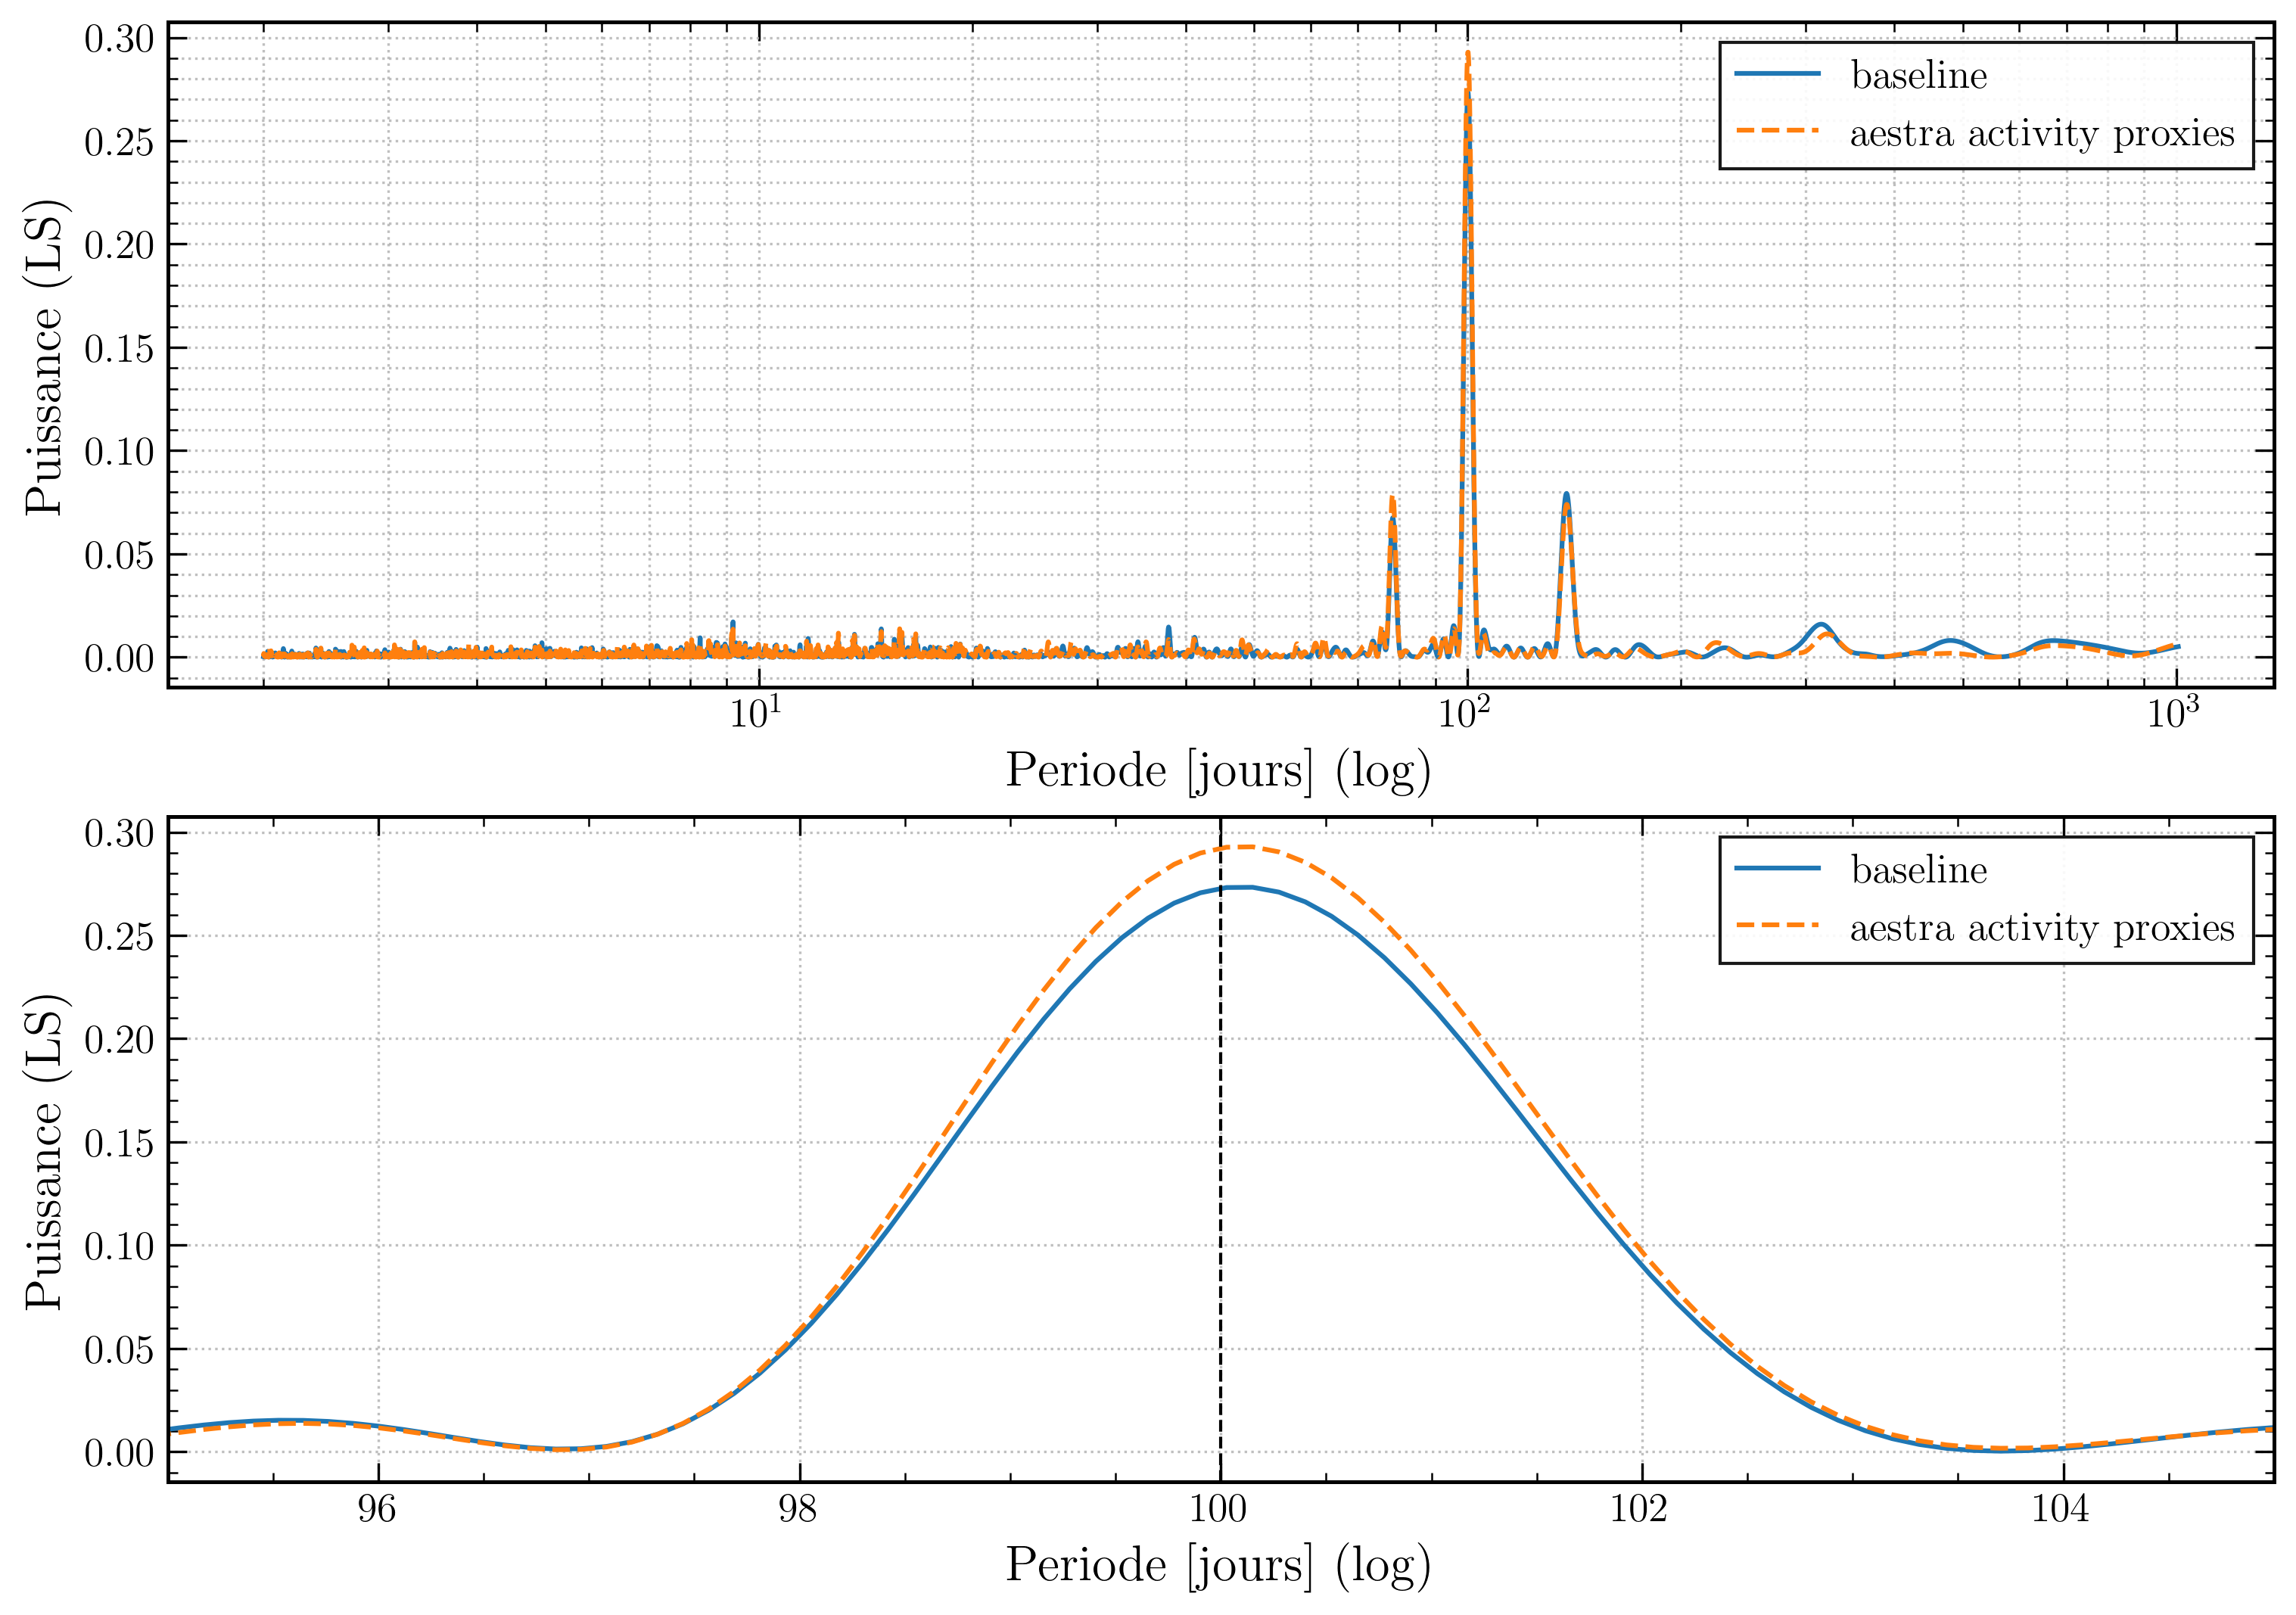

Comparing periodograms.npz vs periodograms.npz


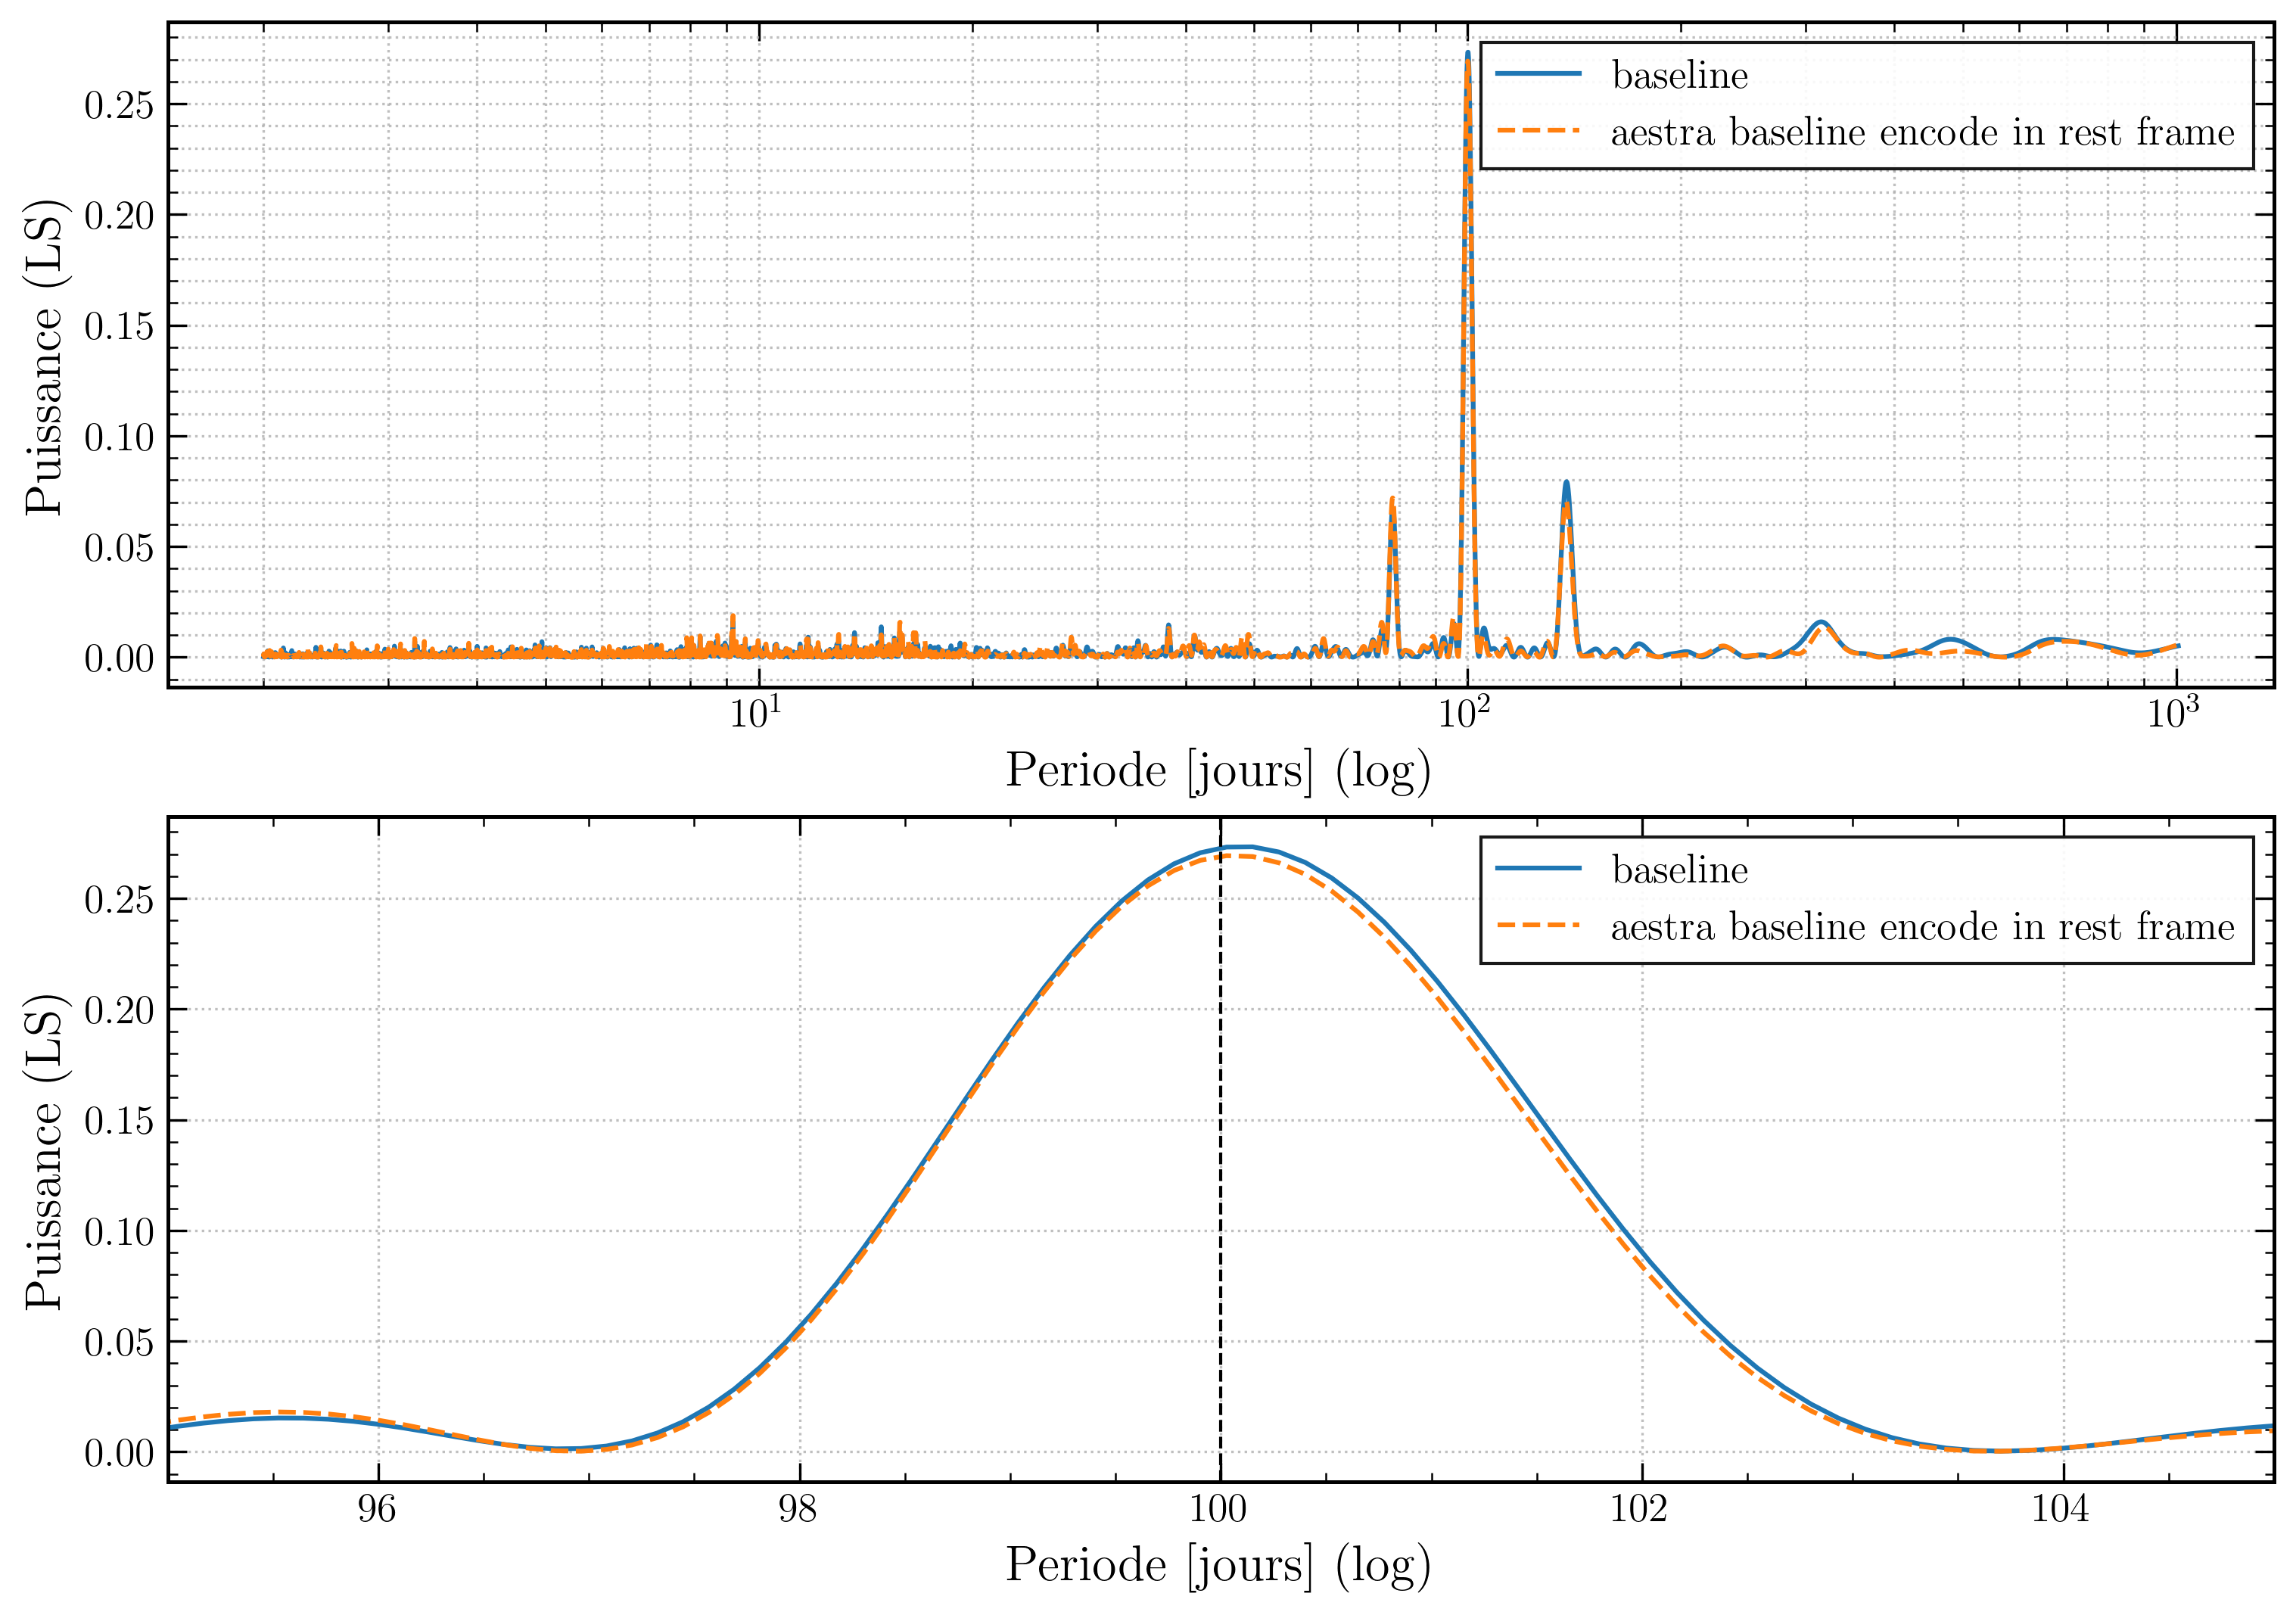

Comparing periodograms.npz vs periodograms.npz


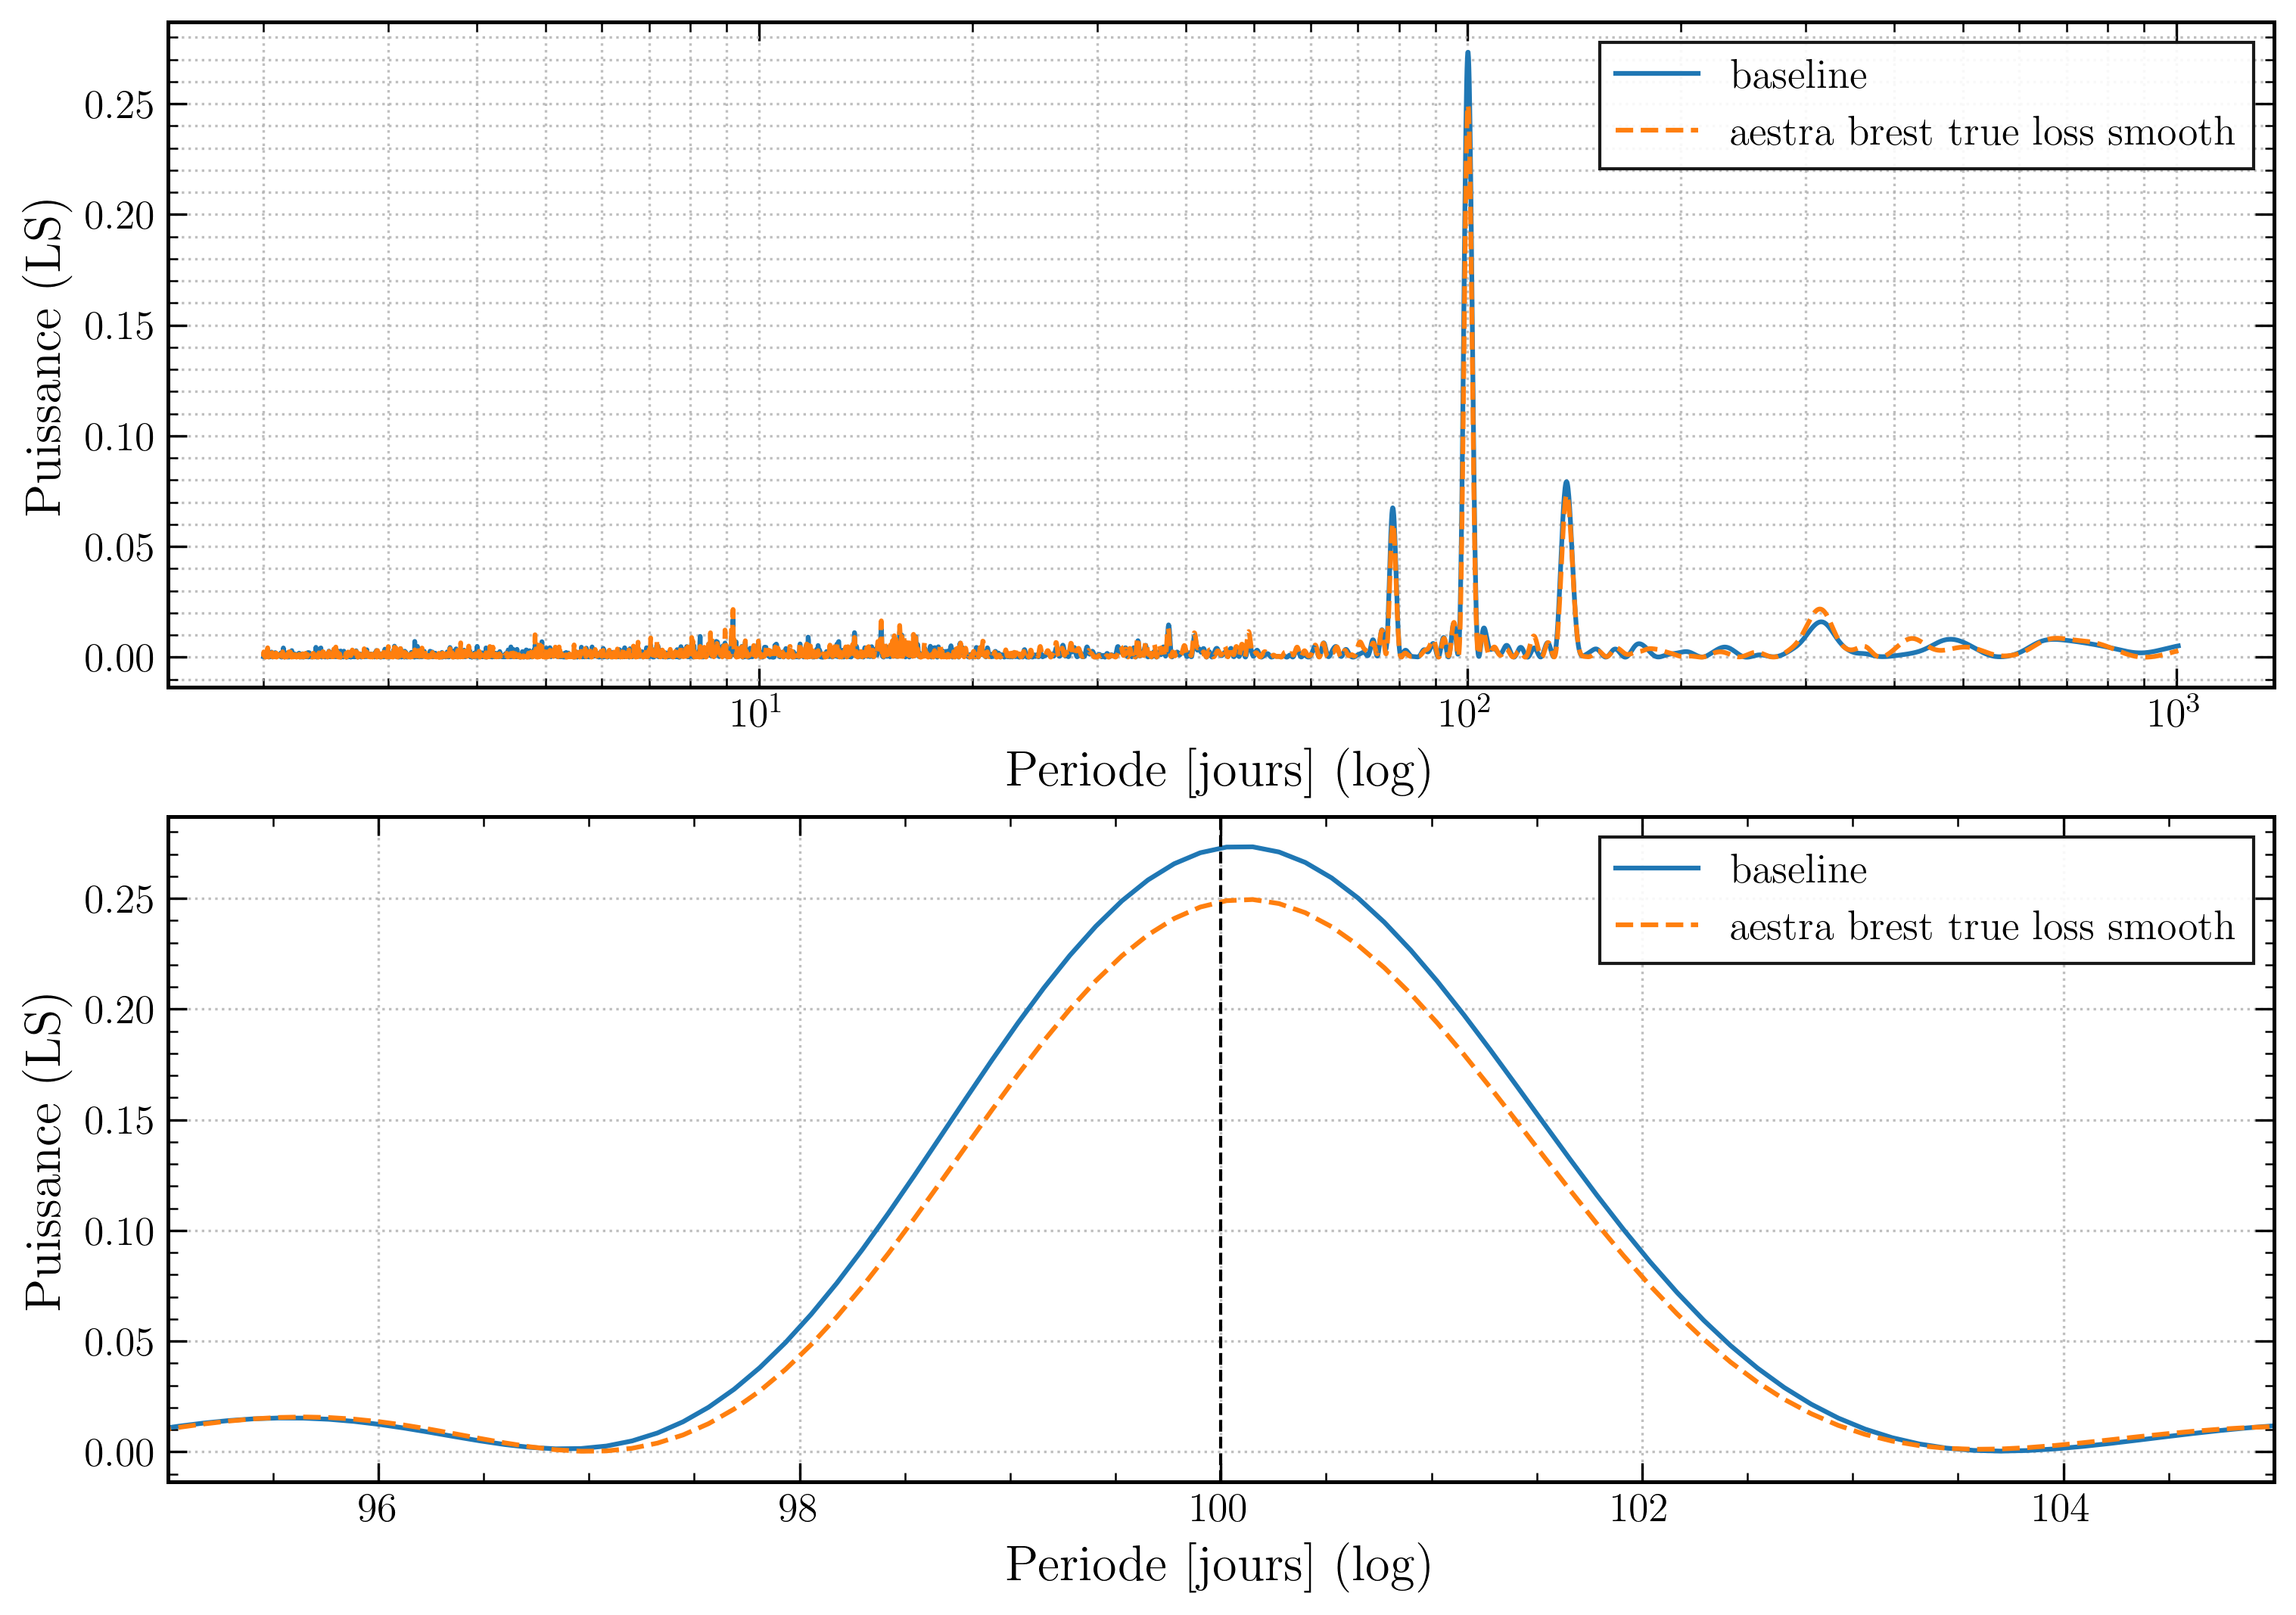

In [21]:
# Compare baseline vs experiments for the 'v_correct' periodogram and zoom around period=100 days
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_compare_v_correct(baseline_path, exp_path, zoom_center=100.0, zoom_halfwidth=5.0):
    b = np.load(str(baseline_path), allow_pickle=True)
    e = np.load(str(exp_path), allow_pickle=True)
    e_name = str(exp_path).split('/')[-4].split('_colab')[0].replace('_', ' ')  # Extract experiment name from path
    key_p = 'v_correct_periods'
    key_power = 'v_correct_power'
    if key_p not in b.files or key_power not in b.files:
        print(f"Baseline missing keys in {baseline_path}: {b.files}")
        return
    if key_p not in e.files or key_power not in e.files:
        print(f"Experiment missing keys in {exp_path}: {e.files}")
        return
    bp = np.asarray(b[key_p], dtype=float)
    bpow = np.asarray(b[key_power], dtype=float)
    ep = np.asarray(e[key_p], dtype=float)
    epow = np.asarray(e[key_power], dtype=float)
    # sort by period
    si = np.argsort(bp); bp, bpow = bp[si], bpow[si]
    si = np.argsort(ep); ep, epow = ep[si], epow[si]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)
    ax = axes[0]
    ax.plot(bp, bpow, label='baseline', color='C0')
    ax.plot(ep, epow, label=f"{e_name}", color="C1", linestyle="--")
    ax.set_xscale('log')
    ax.set_xlabel('Periode [jours] (log)')
    ax.set_ylabel('Puissance (LS)')
    ax.legend()
    ax.grid(True, which='both')

    ax = axes[1]
    ax.plot(bp, bpow, label='baseline', color='C0')
    ax.plot(ep, epow, label=f"{e_name}", color="C1", linestyle="--")
    ax.set_xlim(zoom_center - zoom_halfwidth, zoom_center + zoom_halfwidth)
    ax.set_xlabel("Periode [jours] (log)")
    ax.set_ylabel("Puissance (LS)")
    ax.axvline(zoom_center, color='k', ls='--', lw=1)
    ax.legend()
    ax.grid(True)

    plt.show()

# Discover all periodograms.npz files (same pattern as earlier cell)
periodogram_files = list(Path('../experiments').rglob('*colab/postprocessing/data/periodograms.npz'))
print(f'Found {len(periodogram_files)} periodograms files')
if len(periodogram_files) == 0:
    print('No periodogram files found under ../experiments')
else:
    # Choose baseline: prefer a file path containing 'aestra_baseline' if present
    baseline_candidates = [p for p in periodogram_files if 'aestra_baseline' in str(p)]
    baseline = baseline_candidates[0] if baseline_candidates else periodogram_files[0]
    print('Using baseline:', baseline)
    # Compare baseline to every other file
    for f in periodogram_files:
        if f == baseline:
            continue
        print('Comparing', baseline.name, 'vs', f.name)
        try:
            plot_compare_v_correct(baseline, f, zoom_center=100.0, zoom_halfwidth=5.0)
        except Exception as exc:
            print('Error plotting', f, exc)


[14:52:47] 📂 Loading experiment checkpoint:                                                           ]8;id=717899;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=574666;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#229\229]8;;\
           /home/tliopis/Codes/exoplanets_llopis_mary_2025/experiments/aestra_brest_true_loss_smooth_c             
           olab/models/aestra_final.pth                                                                            

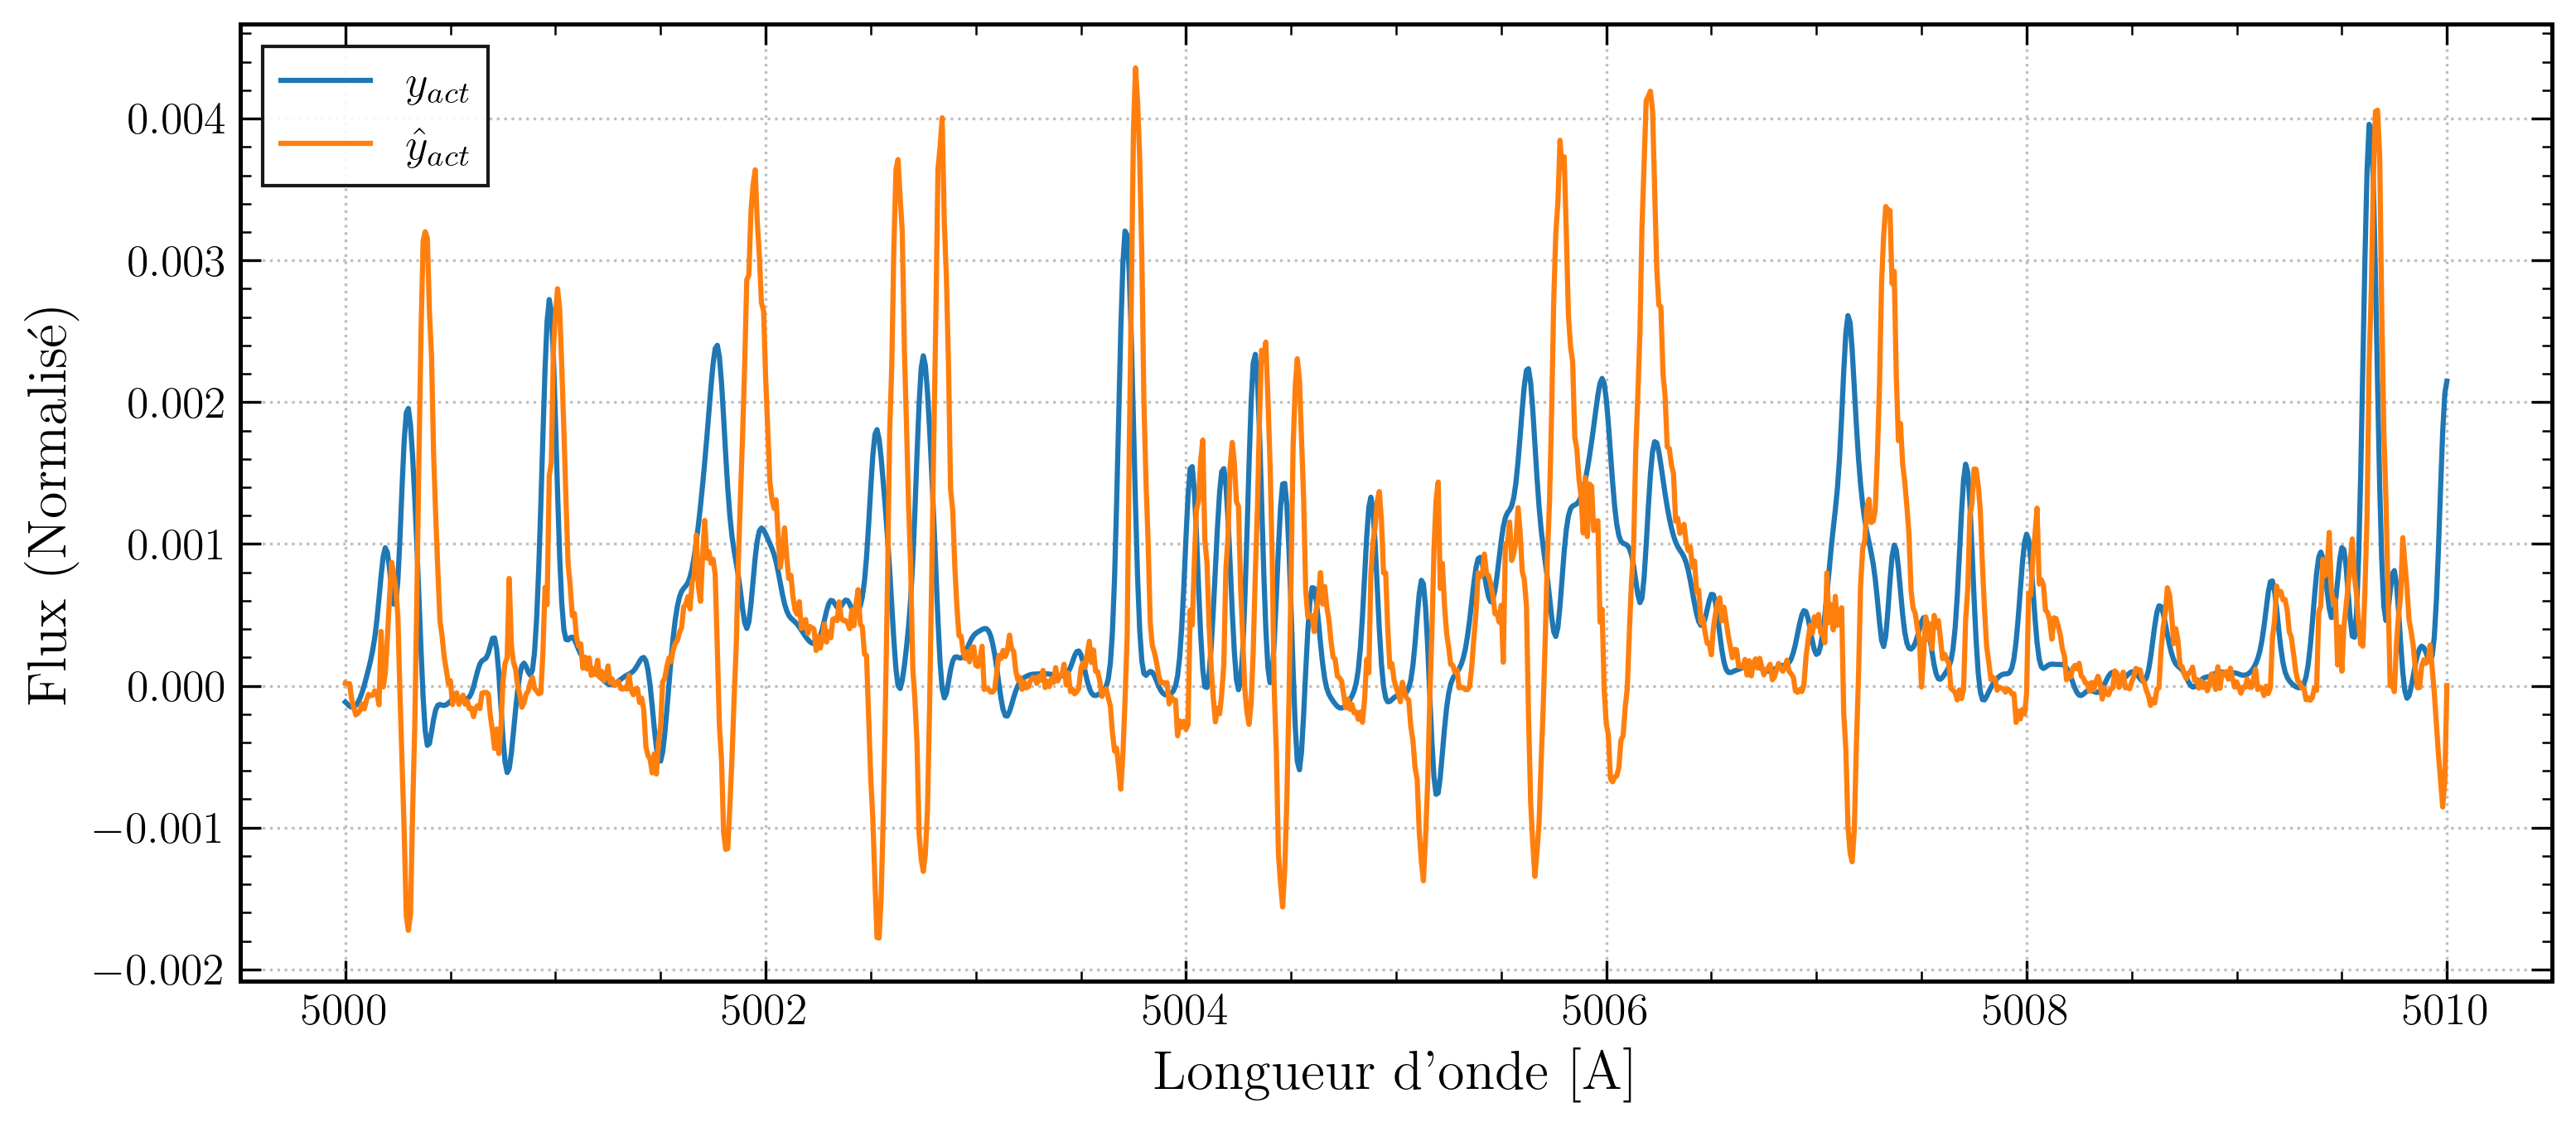

In [ ]:
from src.modeling.train import load_experiment_checkpoint

ckpt = load_experiment_checkpoint(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/experiments/aestra_brest_true_loss_smooth_colab/models/aestra_final.pth",
    dataset_filepath="../data/npz_datasets/soapgpu_ns1275_5000-5010_snr2000_p100_k0p5_phi0.npz",
    device="cpu",
)

ckpt_dset = ckpt["dataset"]
ckpt_model = ckpt["model"]


from src.modeling.train import load_experiment_checkpoint
from src.dataset import generate_collate_fn


# Préparer DataLoader
collate_fn = generate_collate_fn(ckpt_dset)
dataloader = DataLoader(ckpt_dset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Modèle en évaluation sur CPU
ckpt_model.eval()
device = torch.device("cpu")
ckpt_model.to(device)

for batch in dataloader:
    batch_yobs = batch[0].to("cpu")  # [B, P]
    batch_yact_true = batch[6].to("cpu")  # [B, P]
    batch_wavegrid = batch[3].to("cpu")
    batch_vencode = ckpt_model.rvestimator(batch_yobs - ckpt_model.b_rest)

    batch_yact, batch_s = ckpt_model.spender(batch_yobs - ckpt_model.b_rest)

    idx = 30
    wavegrid = batch_wavegrid[idx].detach().cpu().numpy()
    yact_true = batch_yact_true[idx].detach().cpu().numpy()
    yact = batch_yact[idx].detach().cpu().numpy()

    # plot de 1 activitée
    plt.figure(figsize=(12, 5))
    plt.plot(wavegrid, yact_true, label="$y_{act}$")
    plt.plot(wavegrid, yact, label="$\hat{y}_{act}$")
    plt.xlabel("Longueur d'onde [A]")
    plt.ylabel("Flux (Normalisé)")
    plt.grid()
    plt.legend()
    plt.show()

    break



In [28]:
batch_wavegrid.detach().cpu().numpy()[0].shape
batch_yact.detach().cpu().numpy()[0].shape

(1001,)